# PHYS 310 Final Project, 2D Ising Model
## By Niphitphon (Saint) Sachdev ID: 71564371


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import pickle, os


# sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Wanted to try from Wetzel's paper
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

NOTE: Since I will be using pytorch instead of tensorflow like taught in class, I will try to comment and explain each thing

The reason I am using pytorch is because in my future projects, I plan to use pytorch as well so I thought I would get my hands on it now


As I am arranging the notebook once again, I would like to inform you that, if you try to run this locally, it may not work. 
Pytorch has a device setting that you can use, by default it should be CPU but I am unsure of if that will work for windows, you can change it to gpu as well via this code if you are using CUDA.
```Python 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

For mac, you can replace cuda with MPS and it should still work I believe, though I found this out after finishing my rewrite of the notebook hence I did not modify it.
If you do this then you will need to change some of the code and add device to it to make it work!

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED) # setting seed for reproducibility

Tc_exact = 2.0 / np.log(1 + np.sqrt(2.0))
T_vals = np.round(np.arange(0.25, 4.25, 0.25), 2)
L = 40
n_spins = L*L
n_per_T = 10_000 # this is the mote carlo configs per temperature, you can see this from the shape of the data from each T files, ie, 0.25, 0.5 etc



print(f'Exact Tc = {Tc_exact:.4f} J/k_B')
print(f'Temperatures: {T_vals}')

Exact Tc = 2.2692 J/k_B
Temperatures: [0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5
 3.75 4.  ]


# Data Loading and Preprocessing

In [3]:
data = pickle.load(open("./Ising2DFM_reSample_L40_T=All.pkl", 'rb'))


In [4]:
data = np.unpackbits(data).astype(int).reshape(-1,1600)

In [5]:
print("total", data.shape) #checking shape of total
def read_t(t,root="./"):
    data = pickle.load(open(root+'Ising2DFM_reSample_L40_T=%.2f.pkl'%t,'rb'))
    return np.unpackbits(data).astype(int).reshape(-1,1600)


total (160000, 1600)


In [6]:
read_t(0.25).shape # dimensions of each temperature, this has 10_000 monte carlo config and 1600 spins, 40 * 40

(10000, 1600)

In [7]:
def load_data(data_dir="./"):
    X_list, y_list = [],[]

    for t in T_vals:
        filepath = os.path.join(data_dir+'Ising2DFM_reSample_L40_T=%.2f.pkl'%t)
        with open(filepath, 'rb') as f:
            raw_data = pickle.load(f)

        configs = np.unpackbits(raw_data).astype(np.int8).reshape(-1, 1600)
        configs = 2 * configs - 1 # spins are now in -1 and + 1 instead of 0 and 1, we remap it
        label = np.int8(1) if t < Tc_exact else np.int8(0)
        X_list.append(configs)
        y_list.append(np.full(n_per_T, label, dtype=np.int8))
        
    X = np.concatenate(X_list)
    y = np.concatenate(y_list)
    T_per = np.repeat(T_vals, n_per_T)

    print(f'X: {X.shape} dtype={X.dtype} Values={np.unique(X).tolist()}')
    print(f'y: FM = {y.sum():,} PM={(1-y).sum():,}')
    return X, y, T_per

In [8]:
X, y, T_per = load_data() # shows that the shape is correct and as expected

X: (160000, 1600) dtype=int8 Values=[-1, 1]
y: FM = 90,000 PM=70,000


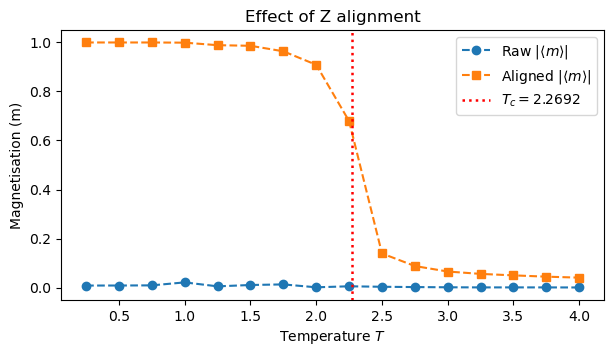

In [9]:
def align_z2(X_arr):
    out = X_arr.copy()
    out[X_arr.mean(axis=1) < 0] *= -1
    return out
# we do this flip because the Hamiltonian is symmetric under the global spin flip, it will pick either m = 1 or -1 below Tc with equal probability.
# so the fix is to simply flip any config with m < 0 so that all FM configs consistently have m > 0


X_al = align_z2(X) # for supervised learning

raw_m = np.array([X[T_per == t].mean(axis=1).mean() for t in T_vals]) # first mean is the m of each config whereas the second one is the average over the temperature
aligned_m = np.array([X_al[T_per == t].mean(axis=1).mean() for t in T_vals])

fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(T_vals, np.abs(raw_m), 'o--', label=r'Raw $|\langle m \rangle|$')
ax.plot(T_vals, np.abs(aligned_m), 's--', label=r'Aligned $|\langle m \rangle|$')
ax.axvline(Tc_exact, color='r', ls=':', lw=1.8, label=f'$T_c = {Tc_exact:.4f}$')
ax.set_xlabel('Temperature $T$')
ax.set_ylabel('Magnetisation (m)')
ax.set_title('Effect of Z alignment')
ax.legend()
plt.tight_layout
plt.savefig('images/z_alignment.png', dpi=150)
plt.show()

It is expected that at High T, m is 0 because it is disordered but now at lower T, the magnetisation is no longer 0

# Data Exploration

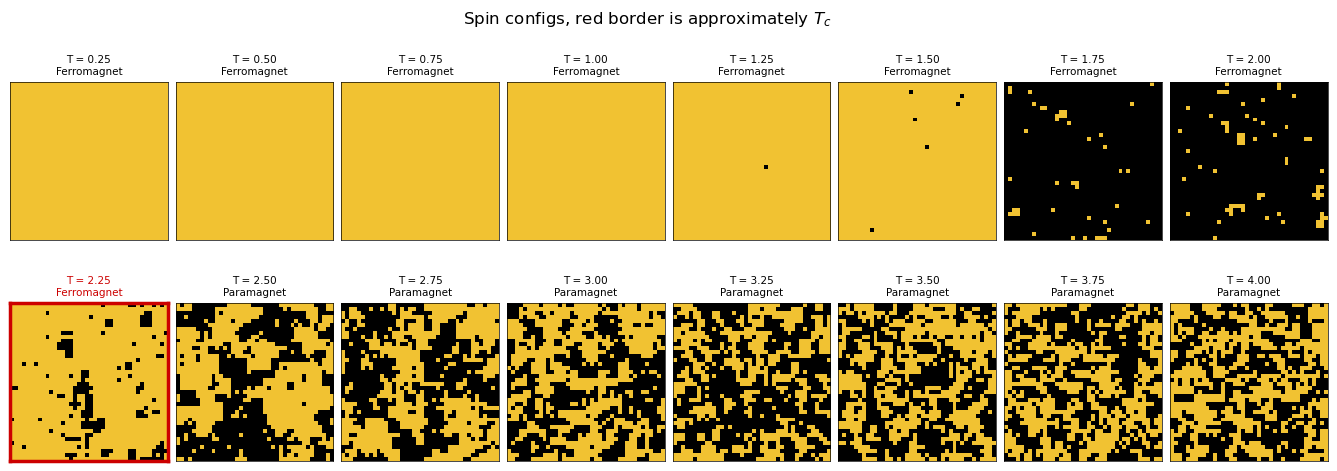

In [10]:
# high light where it changes
rng = np.random.default_rng(SEED)
cmap = ListedColormap(['#000000', '#f1c232'])

fig, axes = plt.subplots(2, 8, figsize=(17, 5), gridspec_kw={'wspace':0.05, 'hspace':0.35})
for ax, t in zip(axes.flat, T_vals):
    idx = rng.choice(np.where(T_per == t)[0])
    ax.imshow(X[idx].reshape(40,40), cmap=cmap, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([]) # to hid the ticks
    near_tc = abs(t-Tc_exact) < 0.15
    phase = 'Ferromagnet' if t < Tc_exact else 'Paramagnet'
    color = "#cc0000" if near_tc else 'black'
    ax.set_title(f'T = {t:.2f}\n{phase}', fontsize=7.5, color = color)
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(2.5 if near_tc else 0.5)
    
fig.suptitle('Spin configs, red border is approximately $T_c$', y=1.02)
plt.savefig('images/lattices.png', bbox_inches='tight', dpi=150)
plt.show()

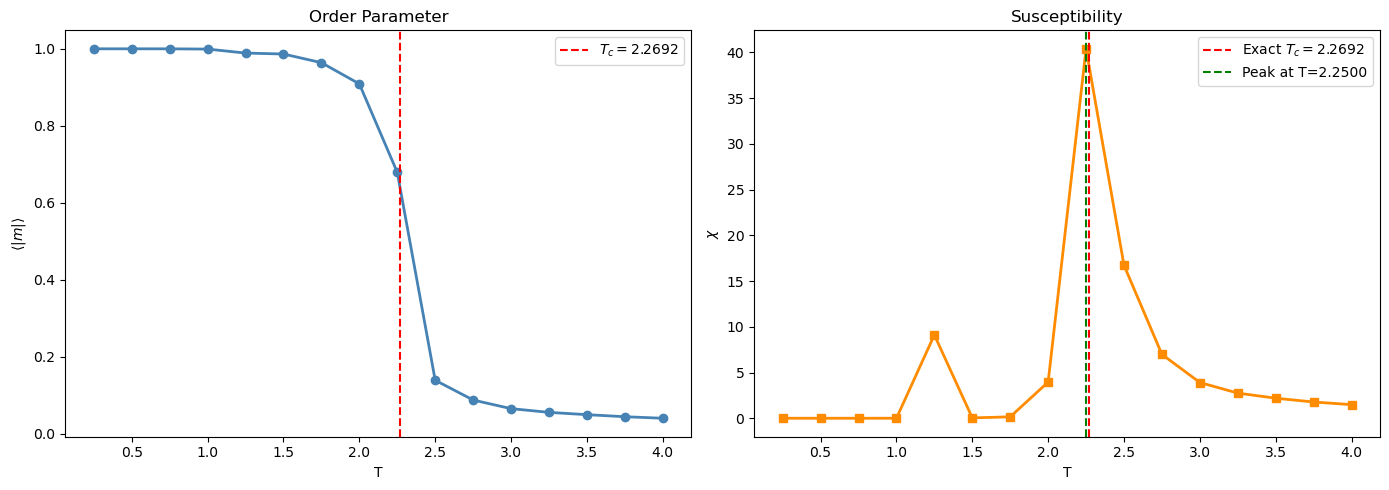

In [11]:
# let's look at order parameter and susceptibility similar to what they do in vritical examination

# first we apply the function to the magnetisation array at each temperature

def perT(func):
    return np.array([func(X[T_per == t].mean(axis=1)) for t in T_vals])

mag = perT(lambda m: np.abs(m).mean())
mag2 = perT(lambda m: (m**2).mean())
chi = n_spins * (mag2 - mag**2)

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(T_vals, mag, 'o-', color='steelblue', lw=2)
axes[0].axvline(Tc_exact, color='r', ls='--', label=f'$T_c = {Tc_exact:.4f}$')
axes[0].set(xlabel='T', ylabel=r'$\langle|m|\rangle$', title='Order Parameter') #expecting it to drop at T_c
axes[0].legend()

axes[1].plot(T_vals, chi, 's-', color='darkorange', lw=2)
axes[1].axvline(Tc_exact, color='r', ls='--', label=f'Exact $T_c = {Tc_exact:.4f}$')
axes[1].axvline(T_vals[chi.argmax()], color='g', ls='--', label=f'Peak at T={T_vals[chi.argmax()]:.4f}')
axes[1].set(xlabel='T', ylabel=r'$\chi$', title='Susceptibility')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/observables.png', dpi = 150)
plt.show()


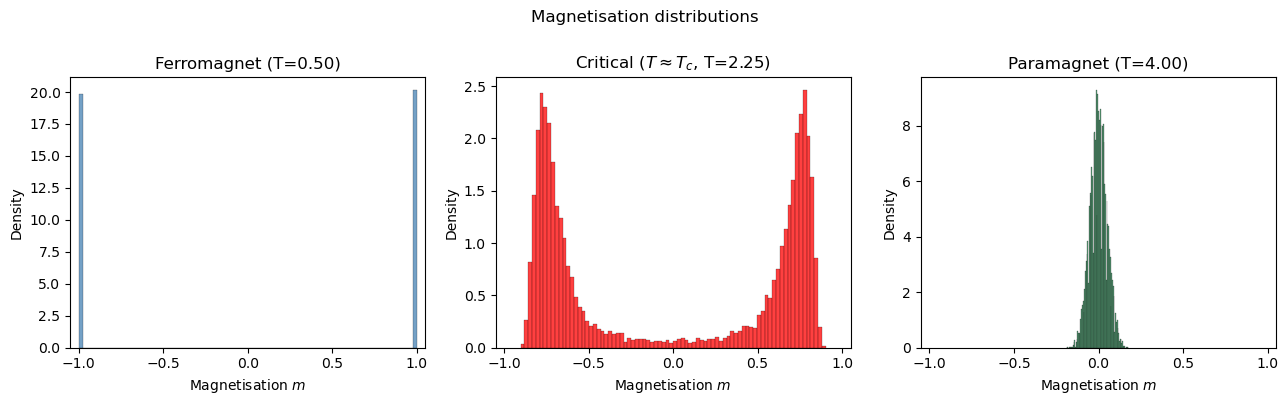

In [12]:
T_hist   = [0.50, 2.25, 4.00]
labels_h = ['Ferromagnet (T=0.50)', r'Critical ($T \approx T_c$, T=2.25)', 'Paramagnet (T=4.00)']
colors_h = ['steelblue', 'red', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, t, label, col in zip(axes, T_hist, labels_h, colors_h):
    m_vals = X[T_per == t].mean(axis=1)
    ax.hist(m_vals, bins=80, color=col, alpha=0.75,
            density=True, edgecolor='k', lw=0.2)
    ax.set_xlabel('Magnetisation $m$')
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.set_xlim(-1.05, 1.05)

plt.suptitle('Magnetisation distributions', y=1.00)
plt.tight_layout()
plt.savefig('images/distributions.png', dpi=150)
plt.show()

---

In [13]:
results = {} # for storing results and comparing them later maybe

# Unsupervised Learning

We will try all three paper's method, PCA, TSNE, Autoencoders. 

Note to self: Do not use the labels by accident and do not used the aligned config

In [14]:
n_pca = 25000
idx_pca = np.random.choice(len(X), n_pca, replace=False) 
# Theorically you could get unlucky and have an unbalanced data but I think it's okay to use this as we have a lot of data
# instead of a more rigorous method
X_pca = X[idx_pca].astype(np.float32)

pca = PCA(n_components=8, random_state=SEED)
pca.fit(X_pca)
Z_pca = pca.transform(X.astype(np.float32))
pc1_per_T = np.array([np.abs(Z_pca[T_per==t,0]).mean() for t in T_vals])
pc2_per_T = np.array([np.abs(Z_pca[T_per==t,1]).mean() for t in T_vals])
pc3_per_T = np.array([np.abs(Z_pca[T_per==t,2]).mean() for t in T_vals])

In [15]:
print('Variance explained per PC')
for k, v in enumerate(pca.explained_variance_ratio_):
    print(f' PC{k+1}: {v*100:.2f}%')
# check if std near 0
print(f'PC1 std {pca.components_[0].std():.2e}')
# e-05 which means it is near uniform! 

Variance explained per PC
 PC1: 51.16%
 PC2: 0.41%
 PC3: 0.39%
 PC4: 0.38%
 PC5: 0.36%
 PC6: 0.31%
 PC7: 0.31%
 PC8: 0.30%
PC1 std 5.63e-05


In [16]:
dpc1 = np.gradient(pc1_per_T, T_vals)
Tc_pca = T_vals[dpc1.argmin()] # grabs the steepest change, this is estimate of T_c
results['PCA'] = (Tc_pca, pc1_per_T / pc1_per_T.max()) # normalise PC1, nan and None aree just placeholders, initially had some code for supervised model as well
print(Tc_pca)
# it is 2.25 most likely because the data is not continuous and also the monte carlo size is L = 40. Otherwise need to simulate more
# option: Might be able to fit to a smooth curve and some how extrapolate from there

2.25


In [17]:
# k means clustering on PC1, PC2
n_k = 5000
idx_k = np.random.choice(len(Z_pca), n_k, replace=False)
Z_k = Z_pca[idx_k, :2] # minimising even more and selecting only 2 columns
T_k = T_per[idx_k]
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km_labels = kmeans.fit_predict(Z_k)

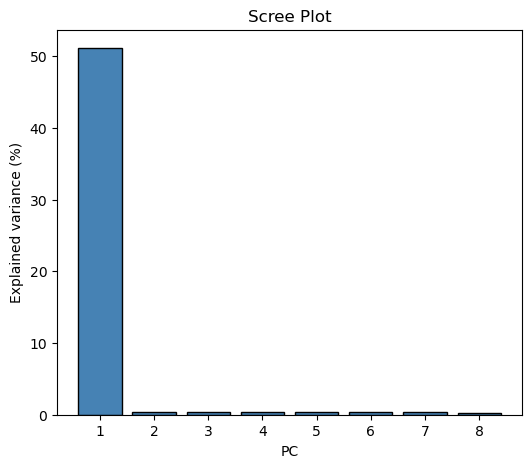

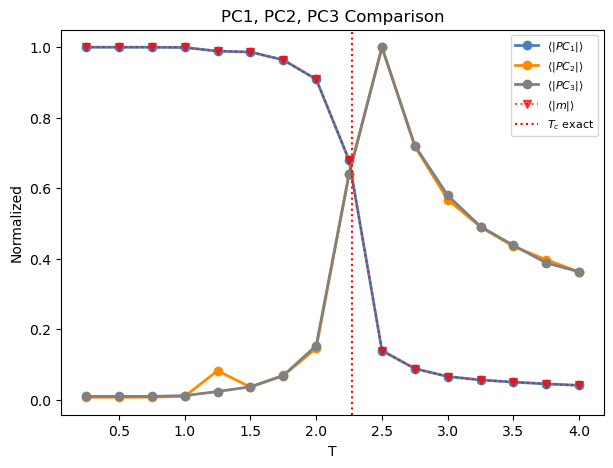

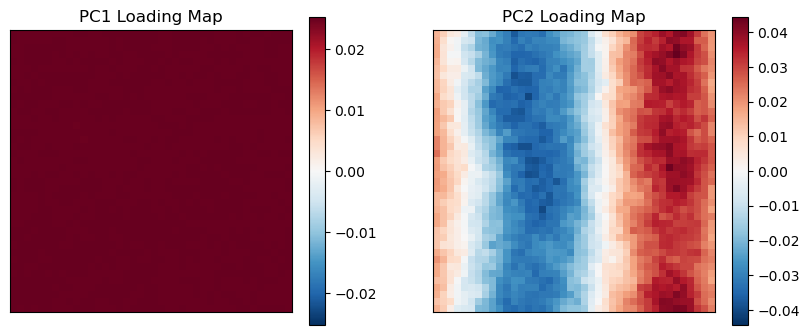

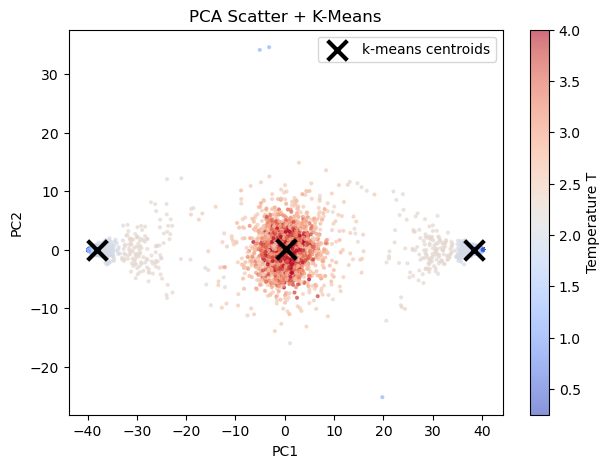

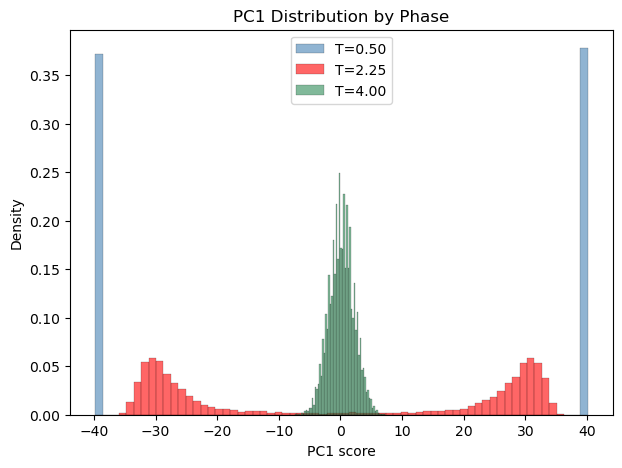

In [18]:
# scree plot, showing which is the most dominant within the 8 PC's
plt.figure(figsize=(6,5))
plt.bar(np.arange(1, 9),pca.explained_variance_ratio_ * 100,color="steelblue",edgecolor="k")

plt.xlabel("PC")
plt.ylabel("Explained variance (%)")
plt.title("Scree Plot")
plt.xticks(range(1, 9))

plt.savefig("images/scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#PC1, PC2, PC3 Comparison

plt.figure(figsize=(7,5))

plt.plot(T_vals,pc1_per_T / pc1_per_T.max(),'o-',color='steelblue',lw=2,label=r'$\langle|PC_1|\rangle$')

plt.plot(T_vals,pc2_per_T / pc2_per_T.max(),'o-',color='darkorange',lw=2,label=r'$\langle|PC_2|\rangle$')

plt.plot(T_vals,pc3_per_T / pc3_per_T.max(),'o-',color='grey',lw=2,label=r'$\langle|PC_3|\rangle$')

plt.plot(T_vals,mag / mag.max(),'v:',color='red',lw=1.5,alpha=0.7,label=r'$\langle|m|\rangle$')

plt.axvline(Tc_exact, color='r', ls=':', lw=1.5, label = '$T_c$ exact')

plt.xlabel("T")
plt.ylabel("Normalized")
plt.title("PC1, PC2, PC3 Comparison")
plt.legend(fontsize=8)

plt.savefig("images/pc123_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# PC1 and 2 loading maps
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# PC1
l1 = pca.components_[0].reshape(40, 40)
vmax = np.abs(l1).max()

im1 = axes[0].imshow(l1,cmap='RdBu_r',vmin=-vmax,vmax=vmax)

plt.colorbar(im1, ax=axes[0], shrink=0.8)
axes[0].set_title("PC1 Loading Map")
axes[0].set_xticks([])
axes[0].set_yticks([])

# PC2
l2 = pca.components_[1].reshape(40, 40)
vmax2 = np.abs(l2).max()

im2 = axes[1].imshow(l2,cmap='RdBu_r',vmin=-vmax2,vmax=vmax2)

plt.colorbar(im2, ax=axes[1], shrink=0.8)
axes[1].set_title("PC2 Loading Map")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.savefig("images/pc_loading_maps.png", dpi=300, bbox_inches="tight")
plt.show()



# scatter plot with K means, Similar to Wang's paper
plt.figure(figsize=(7,5))

sc = plt.scatter(Z_k[:, 0],Z_k[:, 1],c=T_k,cmap='coolwarm',s=4,alpha=0.6)

plt.colorbar(sc, label="Temperature T")

plt.scatter(kmeans.cluster_centers_[:, 0],kmeans.cluster_centers_[:, 1],marker='x',s=200,c='black',lw=3,label='k-means centroids')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter + K-Means")
plt.legend()

plt.savefig("images/pca_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

# distribution 

plt.figure(figsize=(7,5))
for t, col in zip(
    [0.50, 2.25, 4.00],
    ['steelblue', 'red', 'seagreen']
):
    plt.hist(Z_pca[T_per == t, 0],bins=60,density=True,alpha=0.6,color=col,label=f'T={t:.2f}',edgecolor='k',lw=0.2)

plt.xlabel("PC1 score")
plt.ylabel("Density")
plt.title("PC1 Distribution by Phase")
plt.legend()

plt.savefig("images/pc1_distribution_phase.png", dpi=300, bbox_inches="tight")
plt.show()

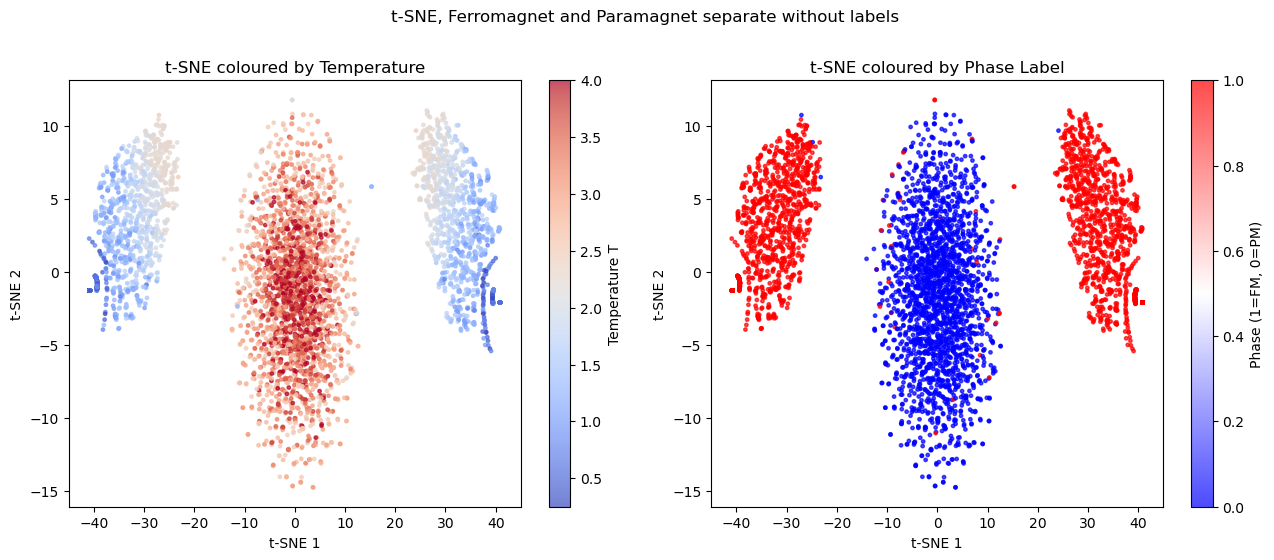

In [19]:
# trying wetzel paper for TSNE
n_tsne = 5000
idx_tsne = np.random.choice(len(X), n_tsne, replace=False)
pca50 = PCA(n_components=50, random_state=SEED)
X_50 = pca50.fit_transform(X[idx_tsne].astype(np.float32))

tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto', init='pca', random_state=SEED, max_iter=1000)
Z_tsne = tsne.fit_transform(X_50)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc1 = axes[0].scatter(Z_tsne[:,0], Z_tsne[:,1], c=T_per[idx_tsne], cmap='coolwarm', s=6, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], label='Temperature T')
axes[0].set(xlabel='t-SNE 1', ylabel='t-SNE 2', title='t-SNE coloured by Temperature')
sc2 = axes[1].scatter(Z_tsne[:,0], Z_tsne[:,1], c=y[idx_tsne], cmap='bwr', s=6, alpha=0.7, vmin=0, vmax=1)
plt.colorbar(sc2, ax=axes[1], label='Phase (1=FM, 0=PM)')
axes[1].set(xlabel='t-SNE 1', ylabel='t-SNE 2', title='t-SNE coloured by Phase Label')
plt.suptitle('t-SNE, Ferromagnet and Paramagnet separate without labels', y=1.01)
plt.tight_layout()
plt.savefig("images/TSNE.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# autoencoders

class Autoencoder(nn.Module):
    def __init__(self, n_in = 1600, n_lat = 2): # n_latent corresponds to magnetisation and phase structure 
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(), # relu justr adds non linearity otherwsie it will be matrix mult.
            nn.Linear(512, 128),  nn.ReLU(),
            nn.Linear(128, 32),   nn.ReLU(),
            nn.Linear(32,  n_lat),
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_lat, 32),  nn.ReLU(),
            nn.Linear(32, 128),    nn.ReLU(),
            nn.Linear(128, 512),   nn.ReLU(),
            nn.Linear(512, n_in),  nn.Tanh(), # Use tanh because spin either +1 or -1 (at first used sigmoid and didn't work)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [21]:
nae = 25000
idx_ae = np.random.choice(len(X), nae, replace = False) # same as the kmean stuff
ae_loader = DataLoader(
    TensorDataset(torch.tensor(X[idx_ae].astype(np.float32))), # multi-dimensional matrix containing elements of a single data type [from docs]
    batch_size = 512, shuffle = True
)

ae = Autoencoder()
opt_ae = optim.Adam(ae.parameters(), lr=1e-3) # uses the adam optimiser
sched_ae = optim.lr_scheduler.StepLR(opt_ae, step_size=25, gamma=0.5) # using it because i find T_c reconstruction to be 4 instead of 2.25
mse = nn.MSELoss() # using the MSE loss function

In [22]:
epochs_ae = 50
ae_losses = []
for ep in range(1, epochs_ae + 1):
    ae.train()
    ep_loss = 0.0
    for (xb,) in ae_loader:
        opt_ae.zero_grad() # clear the gradient: pytorch accumulates automatically by default
        recon, _ = ae(xb)
        loss = mse(recon, xb)
        loss.backward()
        opt_ae.step()
        ep_loss += loss.item() * len(xb) # total loss
    ep_loss /= nae
    sched_ae.step()
    ae_losses.append(ep_loss)
    if ep % 5 == 0 or ep == 1: # just so that it doesn't print every single thing
        print(f'AE Epoch {ep}/{epochs_ae} MSE = {ep_loss}')

AE Epoch 1/50 MSE = 0.589576859035492
AE Epoch 5/50 MSE = 0.47858655668258665
AE Epoch 10/50 MSE = 0.4758558376312256
AE Epoch 15/50 MSE = 0.4746697463226318
AE Epoch 20/50 MSE = 0.47299381547927855
AE Epoch 25/50 MSE = 0.4718872567653656
AE Epoch 30/50 MSE = 0.47060862575531004
AE Epoch 35/50 MSE = 0.4701471666526794
AE Epoch 40/50 MSE = 0.46969086381912234
AE Epoch 45/50 MSE = 0.4692545312786102
AE Epoch 50/50 MSE = 0.46876401100158693


In [23]:
# encoding all 160,000 configs
ae.eval()
all_latent, all_recon_err = [],[]

with torch.no_grad(): #no need to compute gradient because now it is no longer training! 
    for (xb, ) in DataLoader(
        TensorDataset(torch.tensor(X.astype(np.float32))),
        batch_size = 2048, shuffle = False
    ):
        recon, z = ae(xb)
        all_latent.append(z.numpy())
        all_recon_err.append(((recon-xb)**2).mean(dim=1).numpy()) # here we used mean squared error, 1 error per config.
Z_ae = np.concatenate(all_latent)
recon_e = np.concatenate(all_recon_err)

In [24]:
recon_per_T = np.array([recon_e[T_per == t].mean() for t in T_vals])
Z1_per_T = np.array([np.abs(Z_ae[T_per == t, 0]).mean() for t in T_vals])
# Tc_ae_recon = T_vals[recon_per_T.argmax()] # estimating T_c from error: this gave me T = 4.00
# not expected, mistake was did not use gradient. Note to grader, still not entirely sure why
Tc_ae_recon = T_vals[np.gradient(recon_per_T, T_vals).argmax()]
Tc_ae_Z1 = T_vals[np.gradient(Z1_per_T, T_vals).argmin()] # estimating T_c from laten structure
results['AE (|Z1|)'] = (Tc_ae_Z1, np.nan, np.nan, None, None, None)
print(f'AE T_c recon error peak: {Tc_ae_recon:.4f}')
print(f'AE T_c |Z1|: {Tc_ae_Z1:.4f}')
print(f'T_c exact : {Tc_exact:.4f}')

AE T_c recon error peak: 2.2500
AE T_c |Z1|: 2.2500
T_c exact : 2.2692


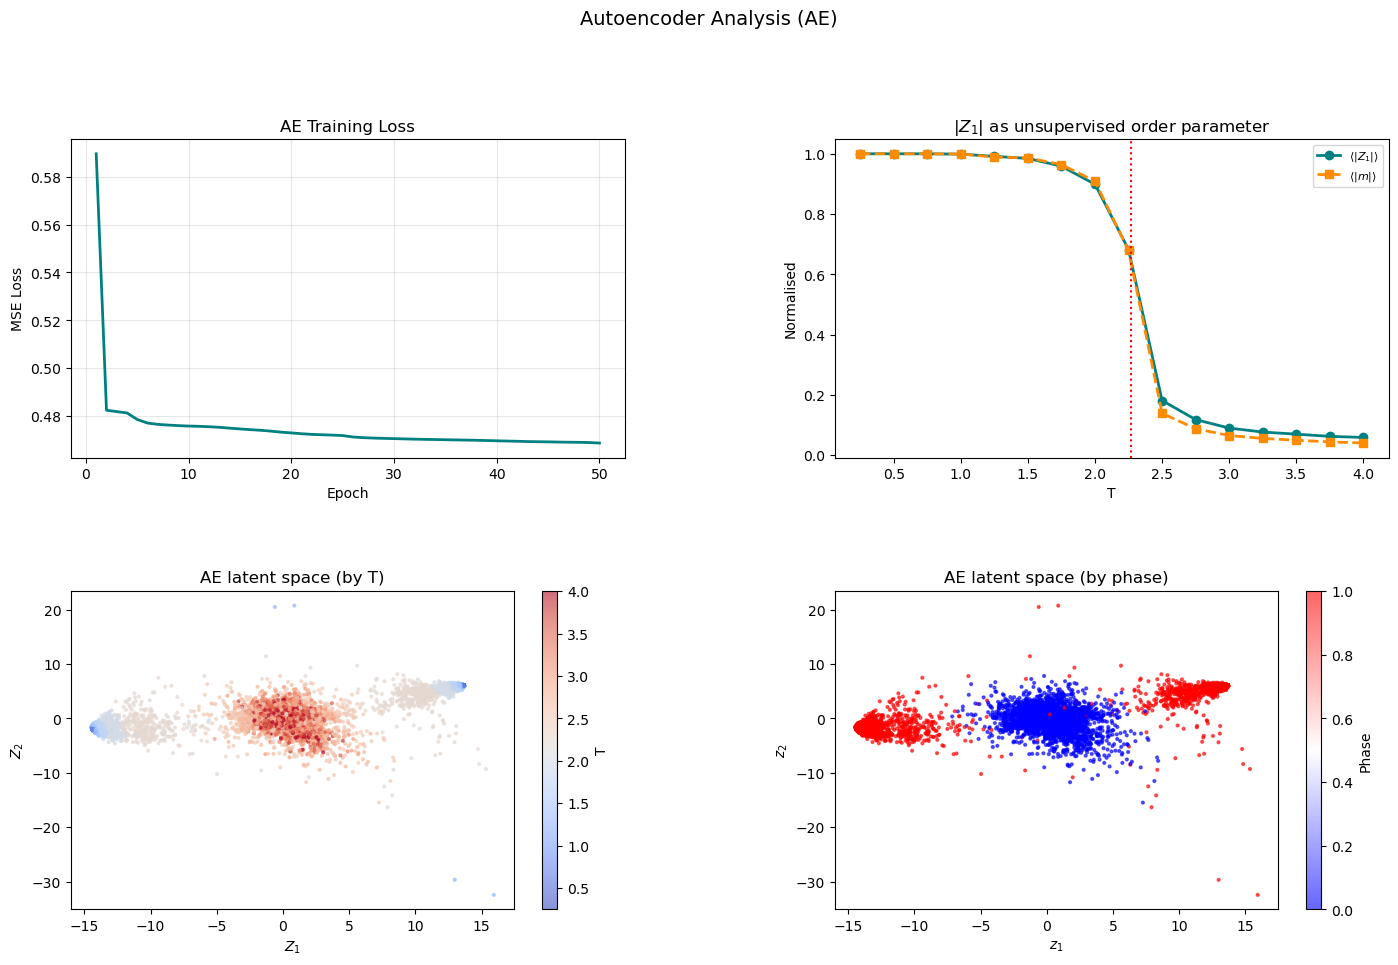

In [25]:
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 2, wspace=0.38, hspace=0.42)

ax = fig.add_subplot(gs[0, 0])
ax.plot(range(1, epochs_ae+1), ae_losses, lw=2, color='teal')
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='AE Training Loss')
ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 1])
ax.plot(T_vals, Z1_per_T/(Z1_per_T.max()+1e-8), 'o-', color='teal', lw=2, label=r'$\langle|Z_1|\rangle$')
ax.plot(T_vals, mag/(mag.max()+1e-8), 's--', color='darkorange', lw=2, label=r'$\langle|m|\rangle$')
ax.axvline(Tc_exact, color='r', ls=':', lw=1.5)
ax.set(xlabel='T', ylabel='Normalised', title=r'$|Z_1|$ as unsupervised order parameter')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 0])
idx_s = np.random.choice(len(Z_ae), 10000, replace=False)
sc = ax.scatter(Z_ae[idx_s,0], Z_ae[idx_s,1], c=T_per[idx_s], cmap='coolwarm', s=4, alpha=0.6)
plt.colorbar(sc, ax=ax, label='T')
ax.set(xlabel='$Z_1$', ylabel='$Z_2$', title='AE latent space (by T)')

ax = fig.add_subplot(gs[1, 1])
sc2 = ax.scatter(Z_ae[idx_s,0], Z_ae[idx_s,1], c=y[idx_s], cmap='bwr', s=4, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc2, ax=ax, label='Phase')
ax.set(xlabel='$z_1$', ylabel='$z_2$', title='AE latent space (by phase)')


plt.savefig("images/AE.png", dpi=300, bbox_inches="tight")
plt.suptitle('Autoencoder Analysis (AE)', y=1.01, fontsize=14)
plt.show()

## VAEs

In [26]:
class VAE(nn.Module):
    def __init__(self, n_in=1600, n_lat = 1):
        super().__init__()
        self.encoder_shared = nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
        )
        self.fullcon_mu = nn.Linear(32, n_lat)
        self.fullcon_log_var = nn.Linear(32, n_lat)
        self.decoder = nn.Sequential(
            nn.Linear(n_lat, 32),  nn.ReLU(),
            nn.Linear(32,  128),   nn.ReLU(),
            nn.Linear(128, 512),   nn.ReLU(),
            nn.Linear(512, n_in),  nn.Tanh(), 
        )
    def encode(self, x):
        h = self.encoder_shared(x)
        return self.fullcon_mu(h), self.fullcon_log_var(h)
    def reparameterise(self, mu, log_var):
        if self.training:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        return self.decode(z), mu, log_var

def vae_loss(recon, x, mu, log_var, beta = 1):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()) / x.shape[1]
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


In [27]:

n_vae = 25000
idx_vae = np.random.choice(len(X), n_vae, replace=False)
vae_loader = DataLoader(TensorDataset(torch.tensor(X[idx_vae].astype(np.float32))),batch_size=512, shuffle=True)
vae = VAE(n_in = n_spins, n_lat=1)
opt_vae = optim.Adam(vae.parameters(), lr = 1e-3)
sched_vae = optim.lr_scheduler.StepLR(opt_vae, step_size= 10)
beta = 1.0
epochs_vae = 50
vae_total_losses, vae_recon_losses, vae_kl_losses = [], [], []

In [28]:
for ep in range(1, epochs_vae + 1):
    # beta = min(1.0, (ep - 1) / 20)
    beta = min(10, ep / 5)
    vae.train()
    ep_total = ep_recon = ep_kl = 0
    for (xb,) in vae_loader:
        opt_vae.zero_grad()
        recon, mu, log_var = vae(xb)
        loss, rl, kl = vae_loss(recon, xb, mu, log_var, beta)
        loss.backward()
        opt_vae.step()
        ep_total += loss.item() * len(xb)
        ep_recon += rl.item()   * len(xb)
        ep_kl += kl.item()   * len(xb)
    vae_total_losses.append(ep_total / n_vae)
    vae_recon_losses.append(ep_recon / n_vae)
    vae_kl_losses.append(ep_kl / n_vae)
    sched_vae.step()
    if ep % 10 == 0 or ep == 1: # dont want to spam the print function again
        print(f'  Epoch {ep:2d}/{epochs_vae} total={vae_total_losses[-1]:.5f} recon={vae_recon_losses[-1]:.5f} KL={vae_kl_losses[-1]:.5f}')

  Epoch  1/50 total=0.58479 recon=0.57849 KL=0.03152
  Epoch 10/50 total=0.48979 recon=0.48540 KL=0.00220
  Epoch 20/50 total=0.49225 recon=0.48533 KL=0.00173
  Epoch 30/50 total=0.49529 recon=0.48563 KL=0.00161
  Epoch 40/50 total=0.49840 recon=0.48586 KL=0.00157
  Epoch 50/50 total=0.50154 recon=0.48599 KL=0.00156


In [29]:
vae.eval()
# similar to AE again, 
all_mu_vae, all_re_vae = [], []
with torch.no_grad():
    for (xb,) in DataLoader(
        TensorDataset(torch.tensor(X.astype(np.float32))),
        batch_size=2048, shuffle=False
    ):
        recon, mu, _ = vae(xb)
        all_mu_vae.append(mu.numpy())
        all_re_vae.append(((recon - xb)**2).mean(dim=1).numpy())

Z_vae = np.concatenate(all_mu_vae)
recon_err_vae = np.concatenate(all_re_vae)

recon_per_T_vae = np.array([recon_err_vae[T_per == t].mean() for t in T_vals])
Z_abs_per_T_vae = np.array([np.abs(Z_vae[T_per == t, 0]).mean() for t in T_vals])


tc_vae_recon = T_vals[np.gradient(recon_per_T_vae, T_vals).argmax()]
tc_vae_mu = T_vals[np.gradient(Z_abs_per_T_vae, T_vals).argmin()]
results['VAE (recon err)'] = (tc_vae_recon, np.nan, np.nan, None, None, None)
results['VAE (|Z|)'] = (tc_vae_mu, np.nan, np.nan, None, None, None)

In [30]:
print(f'VAE T_c, recon error peak: {tc_vae_recon}')
print(f'VAE T_c, |Z|: {tc_vae_mu}')
print(f'Exact T_c: {Tc_exact}')

VAE T_c, recon error peak: 2.25
VAE T_c, |Z|: 2.25
Exact T_c: 2.269185314213022


<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/var/folders/wy/8d6yy34s7tvbvwjf21qc_hg80000gn/T/ipykernel_87640/3962849210.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.set(xlabel='Magnetisation $m$', ylabel='Latent $\mu$', title='VAE latent vs magnetisation')
/var/folders/wy/8d6yy34s7tvbvwjf21qc_hg80000gn/T/ipykernel_87640/3962849210.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set(xlabel='Latent $\mu$', ylabel='Density', title='Latent histogram\nThree clusters: FM, PM, FM')


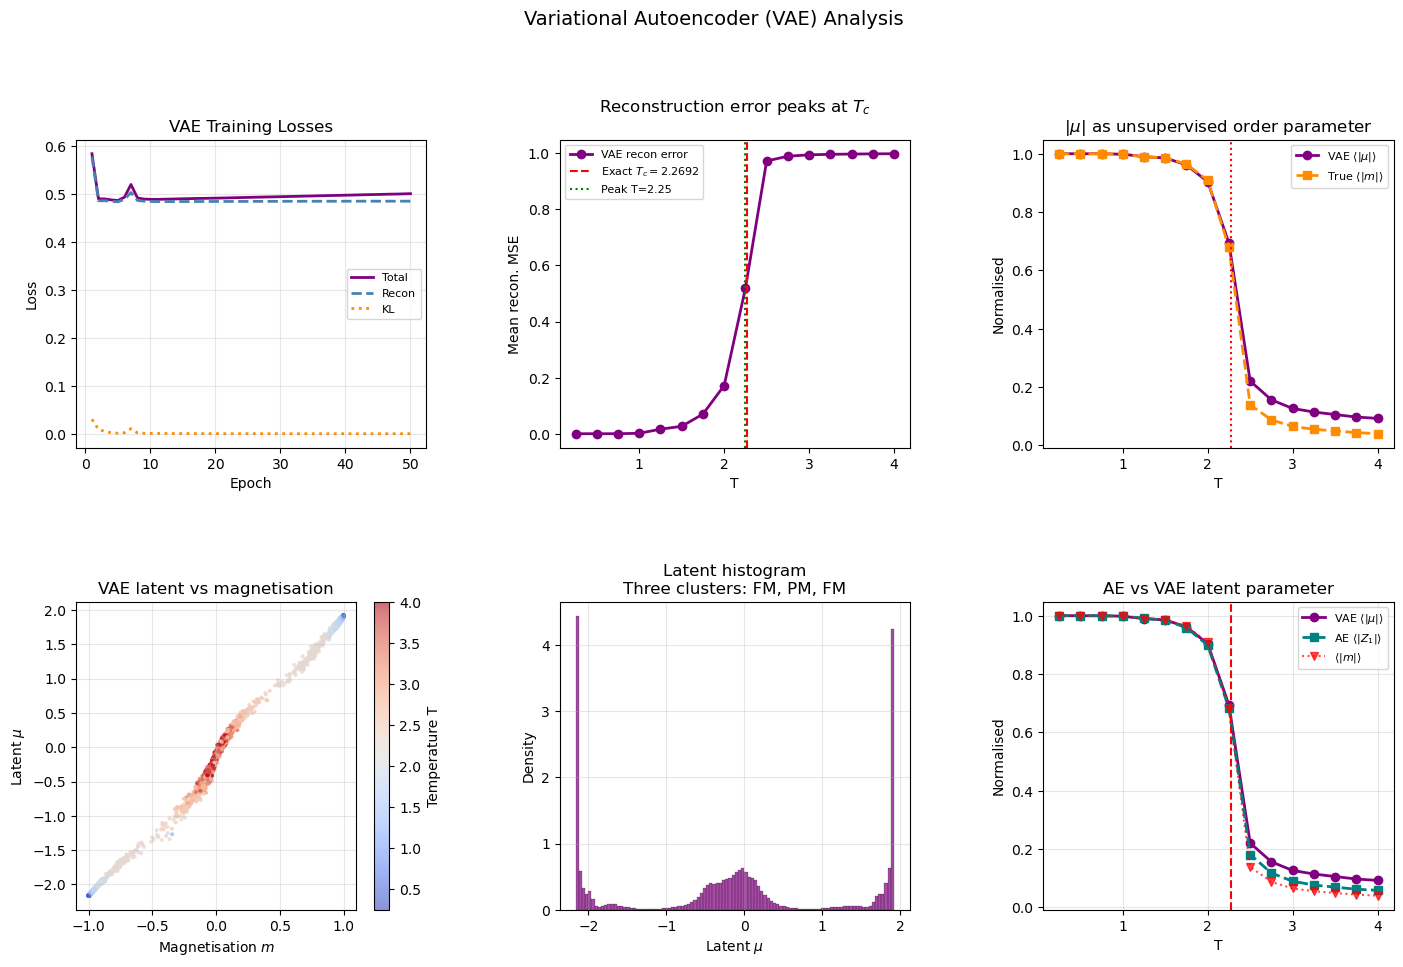

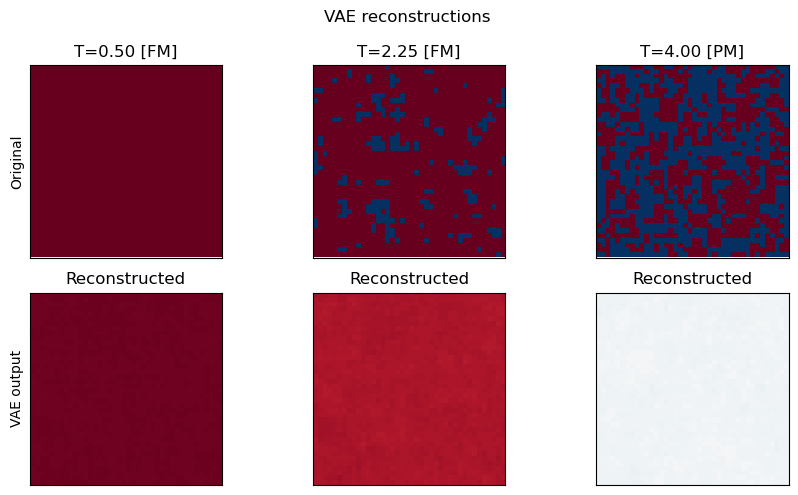

In [40]:
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, wspace=0.38, hspace=0.50)

ax = fig.add_subplot(gs[0, 0])
ax.plot(range(1, epochs_vae+1), vae_total_losses, lw=2, color='purple', label='Total')
ax.plot(range(1, epochs_vae+1), vae_recon_losses, lw=2, color='steelblue',ls='--', label='Recon')
ax.plot(range(1, epochs_vae+1), vae_kl_losses, lw=2, color='darkorange', ls=':', label='KL')
ax.set(xlabel='Epoch', ylabel='Loss', title='VAE Training Losses')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 1])
ax.plot(T_vals, recon_per_T_vae, 'o-', color='purple', lw=2, label='VAE recon error')
ax.axvline(Tc_exact, color='r', ls='--', lw=1.5, label=f'Exact $T_c={Tc_exact:.4f}$')
ax.axvline(tc_vae_recon, color='g', ls=':', label=f'Peak T={tc_vae_recon:.2f}')
ax.set(xlabel='T', ylabel='Mean recon. MSE', title='Reconstruction error peaks at $T_c$\n')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 2])
ax.plot(T_vals, Z_abs_per_T_vae / (Z_abs_per_T_vae.max()+1e-8), 'o-', color='purple', lw=2, label=r'VAE $\langle| \mu |\rangle$')
ax.plot(T_vals, mag / (mag.max()+1e-8), 's--', color='darkorange', lw=2, label=r'True $\langle|m|\rangle$')
ax.axvline(Tc_exact, color='r', ls=':', lw=1.5)
ax.set(xlabel='T', ylabel='Normalised', title=r'$|\mu|$ as unsupervised order parameter')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 0])
idx_s = np.random.choice(len(Z_vae), 5000, replace=False)
m_all = X.mean(axis=1)
sc = ax.scatter(m_all[idx_s], Z_vae[idx_s, 0], c=T_per[idx_s], cmap='coolwarm', s=4, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Temperature T')
ax.set(xlabel='Magnetisation $m$', ylabel='Latent $\mu$', title='VAE latent vs magnetisation')
ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
ax.hist(Z_vae[:, 0], bins=100, density=True, color='purple', alpha=0.7, edgecolor='k', lw=0.2)
ax.set(xlabel='Latent $\mu$', ylabel='Density', title='Latent histogram\nThree clusters: FM, PM, FM')
ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 2])
Z_ae_per_T = np.array([np.abs(Z_ae[T_per==t, 0]).mean() for t in T_vals])
ax.plot(T_vals, Z_abs_per_T_vae / (Z_abs_per_T_vae.max()+1e-8), 'o-', color='purple', lw=2, label=r'VAE $\langle|\mu|\rangle$')
ax.plot(T_vals, Z_ae_per_T / (Z_ae_per_T.max()+1e-8), 's--', color='teal', lw=2, label=r'AE $\langle|Z_1|\rangle$')
ax.plot(T_vals, mag / (mag.max()+1e-8), 'v:', color='red', lw=1.5, alpha=0.7, label=r'$\langle|m|\rangle$')
ax.axvline(Tc_exact, color='r', ls='--', lw=1.5)
ax.set(xlabel='T', ylabel='Normalised', title='AE vs VAE latent parameter')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Variational Autoencoder (VAE) Analysis', y=1.01, fontsize=14)
plt.savefig('images/vae_analysis.png', bbox_inches='tight', dpi=150); plt.show()

# VAE reconstruction
vae.eval()
fig2, axes = plt.subplots(2, 3, figsize=(9, 5))
with torch.no_grad():
    for col, t in enumerate([0.50, 2.25, 4.00]):
        orig = X[np.where(T_per==t)[0][0]].astype(np.float32)
        recon_cfg, _, _ = vae(torch.tensor(orig).unsqueeze(0))
        recon_np  = recon_cfg.squeeze().cpu().numpy().reshape(40,40)
        phase = 'FM' if t < Tc_exact else 'PM'
        axes[0,col].imshow(orig.reshape(L,L), cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
        axes[0,col].set(xticks=[], yticks=[], title=f'T={t:.2f} [{phase}]')
        axes[1,col].imshow(recon_np, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
        axes[1,col].set(xticks=[], yticks=[], title='Reconstructed')
axes[0,0].set_ylabel('Original', fontsize=10)
axes[1,0].set_ylabel('VAE output', fontsize=10)
fig2.suptitle('VAE reconstructions')
fig2.tight_layout()
plt.savefig("images/reconstruction.png", dpi=300, bbox_inches="tight")
plt.show()

# Supervised Model (CNN)

## Splitting Data

In [32]:
gap = 0.5
train_mask = (T_vals < Tc_exact - gap) | (T_vals > Tc_exact + gap) # this is to exclude the critical window from training
# to ensure that they are able to generalise it properly otherwise they may overfit
train = np.isin(T_per, T_vals[train_mask])
# phase
Xp_train = X_al[train].astype(np.float32)
yp_train = y[train]
Xp_test = X_al.astype(np.float32)
yp_test = y
print(f"split is, Train temp: {T_vals[train_mask]}, train: {train.sum()} Test: {len(y)}") # we test on all data
#randomsplit
Xr_tr, Xr_te, yr_tr, yr_te, Tr_tr, Tr_te = train_test_split(
    X_al.astype(np.float32), y, T_per, test_size=0.2, random_state=SEED, stratify=y
)


split is, Train temp: [0.25 0.5  0.75 1.   1.25 1.5  1.75 3.   3.25 3.5  3.75 4.  ], train: 120000 Test: 160000


In [33]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),                                      
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                      
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                      
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)
    
def make_loader(X_arr, y_arr, batch=512, shuffle=True):
    Xt = torch.tensor(X_arr).view(-1, 1, L, L)
    yt = torch.tensor(y_arr.astype(np.float32))
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=shuffle)

In [34]:
cnn = CNN()
opt_cnn = optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4) # added weight decay to prevent overfitting
sched_cnn = optim.lr_scheduler.CosineAnnealingLR(opt_cnn, T_max= 15)
bce = nn.BCEWithLogitsLoss()

In [35]:
loader_train_cnn = make_loader(Xp_train, yp_train)
loader_test_cnn = make_loader(Xr_te, yr_te, shuffle= False)

In [36]:
epochs_cnn = 10
cnn_train_loss = []
cnn_val_acc = []
for ep in range(1, epochs_cnn + 1):
    cnn.train()
    p_loss = 0.0
    for xb, yb in loader_train_cnn:
        opt_cnn.zero_grad()
        loss = bce(cnn(xb), yb)
        loss.backward()
        opt_cnn.step()
        ep_loss += loss.item() * len(yb)
    ep_loss /= len(yp_train)
    sched_cnn.step()

    cnn.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in loader_test_cnn:
            all_p.extend(torch.sigmoid(cnn(xb)).tolist())
            all_t.extend(yb.tolist())

    val_acc = accuracy_score(all_t, [p > 0.5 for p in all_p])
    cnn_train_loss.append(ep_loss)
    cnn_val_acc.append(val_acc)
    if ep % 3 == 0 or ep == 1:
        print(f'Epoch {ep:2d}/{epochs_cnn} loss={ep_loss:.4f}  val_acc={val_acc:.4f}')

all_p_cnn = np.array(all_p)
all_t_cnn = np.array(all_t, dtype=int)
acc_cnn = accuracy_score(all_t_cnn, (all_p_cnn > 0.5).astype(int))
auc_cnn = roc_auc_score(all_t_cnn, all_p_cnn)
fpr_cnn, tpr_cnn, _ = roc_curve(all_t_cnn, all_p_cnn)

Epoch  1/10 loss=0.0077  val_acc=0.9955
Epoch  3/10 loss=0.0000  val_acc=0.9948
Epoch  6/10 loss=0.0000  val_acc=0.9943
Epoch  9/10 loss=0.0000  val_acc=0.9916


In [37]:
cnn.eval()
probs_full_cnn = []
with torch.no_grad():
    for xb, _ in make_loader(Xp_test, yp_test, batch=2048, shuffle=False):
        probs_full_cnn.extend(
            torch.sigmoid(cnn(xb)).tolist()
        )
probs_full_cnn = np.array(probs_full_cnn)
curve_cnn = np.array([probs_full_cnn[T_per == t].mean() for t in T_vals])
tc_cnn = T_vals[np.argmin(np.abs(curve_cnn - 0.5))]
results['CNN']= (tc_cnn, acc_cnn, auc_cnn, fpr_cnn, tpr_cnn, curve_cnn)
print(f'CNN accuracy = {acc_cnn:.4f} AUC = {auc_cnn:.4f} T_c = {tc_cnn:.4f} err = {abs(tc_cnn - Tc_exact):.4f}')

CNN accuracy = 0.9920 AUC = 1.0000 T_c = 2.2500 err = 0.0192


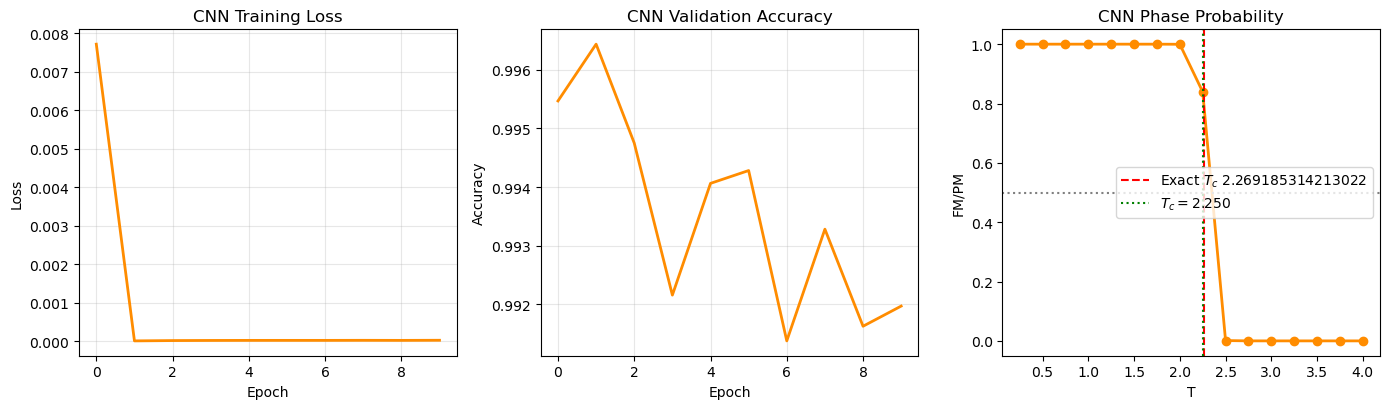

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(cnn_train_loss, lw=2, color='darkorange')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='CNN Training Loss')
axes[0].grid(alpha=0.3)
axes[1].plot(cnn_val_acc, lw=2, color='darkorange')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='CNN Validation Accuracy')
axes[1].grid(alpha=0.3)
axes[2].plot(T_vals, curve_cnn, 'o-', color='darkorange', lw=2)
axes[2].axvline(Tc_exact, color='r', ls='--', label=f'Exact $T_c$ {Tc_exact}')
axes[2].axvline(tc_cnn, color='g', ls=':', label=f'$T_c={tc_cnn:.3f}$')
axes[2].axhline(0.5, color='gray', ls=':')
axes[2].set(xlabel='T', ylabel='FM/PM', title='CNN Phase Probability')
axes[2].legend()
plt.tight_layout()
plt.savefig('images/cnn.png', dpi=300, bbox_inches = 'tight')
plt.show()
